# 메인퀘스트 : Credit Card Fraud Detection
- 예측할 값(y): `Class` (0:Not fraud, 1:fraud)
- 모델 평가 지표 : `f1-score`

### 퀘스트 평가 기준 :

- 데이터 이해 및 탐색: Class의 균형과 데이터의 분포와 특성을 시각화를 통해서 파악했는가?
- 모델 선택 및 비교: 3개 이상의 모델을 학습시키고 성능을 비교했는가?
- 레이블 불균형을 처리하기 위한 기법을 시도했는가?
- 여러 모델을 앙상블을 통해 결합하여 성능을 비교했는가?
- Ridge/Lasso 등의 규제 추가, 트리 기반 모델의 깊이/학습률 등 하이퍼파라미터를 조정하여 성능 향상을 시도했는가?

In [29]:
!pip uninstall -y xgboost lightgbm

Found existing installation: xgboost 1.5.0
Uninstalling xgboost-1.5.0:
  Successfully uninstalled xgboost-1.5.0
Found existing installation: lightgbm 3.3.2
Uninstalling lightgbm-3.3.2:
  Successfully uninstalled lightgbm-3.3.2


In [30]:
!pip install xgboost==1.5.0 lightgbm==3.3.2

  Using cached xgboost-1.5.0-py3-none-manylinux2014_x86_64.whl.metadata (1.7 kB)
  Using cached lightgbm-3.3.2-py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached xgboost-1.5.0-py3-none-manylinux2014_x86_64.whl (173.5 MB)
Using cached lightgbm-3.3.2-py3-none-manylinux1_x86_64.whl (2.0 MB)


In [31]:
!pip install hyperopt

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 훈련 데이터와 테스트 데이터는 미리 준비되어 있습니다.

train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [33]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170883 entries, 0 to 170882
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      170883 non-null  int64  
 1   Time    170883 non-null  float64
 2   V1      170883 non-null  float64
 3   V2      170883 non-null  float64
 4   V3      170883 non-null  float64
 5   V4      170883 non-null  float64
 6   V5      170883 non-null  float64
 7   V6      170883 non-null  float64
 8   V7      170883 non-null  float64
 9   V8      170883 non-null  float64
 10  V9      170883 non-null  float64
 11  V10     170883 non-null  float64
 12  V11     170883 non-null  float64
 13  V12     170883 non-null  float64
 14  V13     170883 non-null  float64
 15  V14     170883 non-null  float64
 16  V15     170883 non-null  float64
 17  V16     170883 non-null  float64
 18  V17     170883 non-null  float64
 19  V18     170883 non-null  float64
 20  V19     170883 non-null  float64
 21  V20     17

In [34]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113923 entries, 0 to 113922
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      113923 non-null  int64  
 1   Time    113923 non-null  float64
 2   V1      113923 non-null  float64
 3   V2      113923 non-null  float64
 4   V3      113923 non-null  float64
 5   V4      113923 non-null  float64
 6   V5      113923 non-null  float64
 7   V6      113923 non-null  float64
 8   V7      113923 non-null  float64
 9   V8      113923 non-null  float64
 10  V9      113923 non-null  float64
 11  V10     113923 non-null  float64
 12  V11     113923 non-null  float64
 13  V12     113923 non-null  float64
 14  V13     113923 non-null  float64
 15  V14     113923 non-null  float64
 16  V15     113923 non-null  float64
 17  V16     113923 non-null  float64
 18  V17     113923 non-null  float64
 19  V18     113923 non-null  float64
 20  V19     113923 non-null  float64
 21  V20     11

## 뼈대 만들기
머신러닝 파이프라인은

데이터 준비 → 모델 정의 → 학습 → 예측 → 평가의 형태를 띕니다.

최소한의 형태로 파이프라인만 구성해 보겠습니다.

In [35]:
train_copy = train_df.copy()
train_copy.drop('Time', axis=1, inplace=True)

## 데이터 이해 및 탐색 (EDA)

1. 클래스 불균형 확인
2. Amount 분포 비교 (Fraud vs Normal)

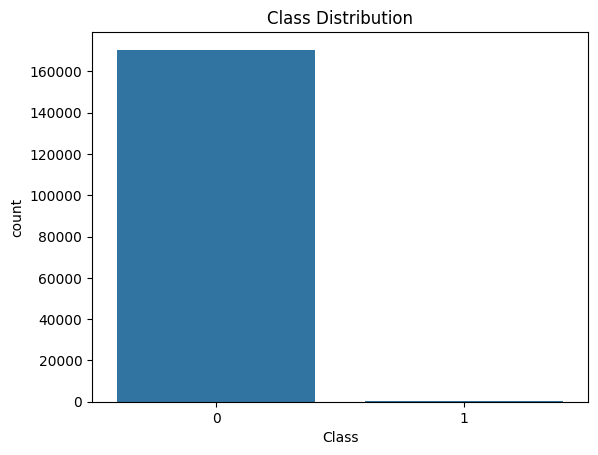

Class
0    0.997893
1    0.002107
Name: proportion, dtype: float64


In [36]:
# 클래스 불균형 확인
sns.countplot(x='Class', data=train_copy)
plt.title("Class Distribution")
plt.show()

print(train_copy['Class'].value_counts(normalize=True))

/tmp/ipython-input-3293905404.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_copy[train_copy['Class']==0]['Amount'], label='Normal', log_scale=True)
/tmp/ipython-input-3293905404.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_copy[train_copy['Class']==1]['Amount'], label='Fraud', log_scale=True)
/tmp/ipython-input-3293905404.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


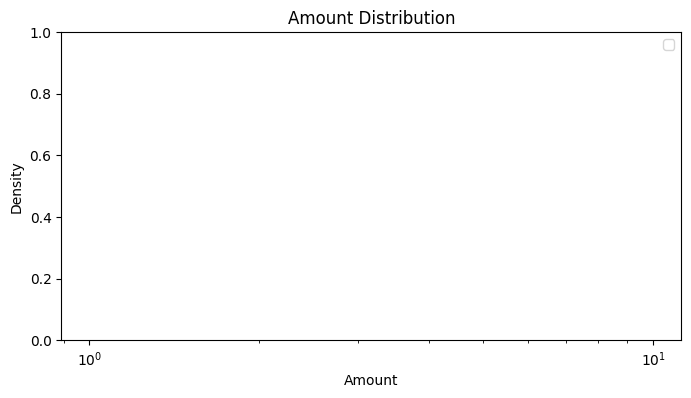

In [37]:
# Amount 분포 비교 (Fraud vs Normal)
plt.figure(figsize=(8,4))
sns.kdeplot(train_copy[train_copy['Class']==0]['Amount'], label='Normal', log_scale=True)
sns.kdeplot(train_copy[train_copy['Class']==1]['Amount'], label='Fraud', log_scale=True)
plt.legend()
plt.title("Amount Distribution")
plt.show()


Amount 분포 비교 그래프를 그리려고 했지만 해당 데이터 분산이 0이라서 밀도 추정을 할 수 없어 그래프가 생략되었다.
- 사기(Class=1)데이터가 너무 적음

=> 사기 데이터의 Amount 분포는 KDE로 보기엔 너무 적거나 특이하다

사기 데이터 희소성을 고려해서 로그 스케일 히스토그램 사용

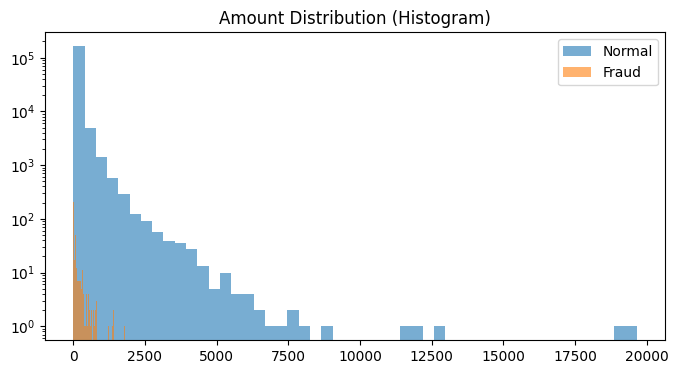

In [38]:
plt.figure(figsize=(8,4))

plt.hist(
    train_copy[train_copy['Class']==0]['Amount'],
    bins=50,
    alpha=0.6,
    label='Normal',
    log=True
)

plt.hist(
    train_copy[train_copy['Class']==1]['Amount'],
    bins=50,
    alpha=0.6,
    label='Fraud',
    log=True
)

plt.legend()
plt.title("Amount Distribution (Histogram)")
plt.show()


## 데이터 전처리
1. Train / Test 분리

2. (Stratified)스케일링
- PCA 성분은 이미 정규화되어 있음
- Amount만 스케일링


In [39]:
# 입력 X 와 y의 분리
X_features = train_copy.iloc[:, :-1]
y_target = train_copy.iloc[:, -1]

In [40]:
# Train / Test 분리 (Stratified)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_features, y_target, test_size=0.2, random_state=42, stratify=y_target)

In [41]:
# 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[['Amount']] = scaler.fit_transform(X_train[['Amount']])
X_val[['Amount']] = scaler.transform(X_val[['Amount']])


In [42]:
print('학습 데이터 간 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('검증 데이터 간 레이블 값 비율')
print(y_val.value_counts()/y_val.shape[0] * 100)

학습 데이터 간 레이블 값 비율
Class
0    99.789329
1     0.210671
Name: count, dtype: float64
검증 데이터 간 레이블 값 비율
Class
0    99.789332
1     0.210668
Name: count, dtype: float64


## 불균형 처리 하기

In [43]:
# 기준모델
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# 학습
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)

# 검증
lr_val = lr_clf.predict(X_val)
lr_val_proba = lr_clf.predict_proba(X_val)[:,1]

print('학습 완료!')


학습 완료!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_val_confusion = confusion_matrix(y_val, lr_val)
lr_val_accuracy = accuracy_score(y_val, lr_val)
lr_val_precision = precision_score(y_val, lr_val)
lr_val_recall = recall_score(y_val, lr_val)
lr_val_f1 = f1_score(y_val, lr_val)

lr_val_roc_score = roc_auc_score(y_val, lr_val_proba)
print(lr_val_roc_score)

print("검증 데이터 혼동행렬:")
print(lr_val_confusion)
print("검증 데이터 정확도: ",lr_val_accuracy)
print("검증 데이터 정밀도: ",lr_val_precision)
print("검증 데이터 재현율: ",lr_val_recall)
print("검증 데이터 F1 점수: ",lr_val_f1)
print("검증 데이터 AUC: ",lr_val_roc_score)

0.9669387023733894
검증 데이터 혼동행렬:
[[34092    13]
 [   28    44]]
검증 데이터 정확도:  0.9988003628170993
검증 데이터 정밀도:  0.7719298245614035
검증 데이터 재현율:  0.6111111111111112
검증 데이터 F1 점수:  0.6821705426356589
검증 데이터 AUC:  0.9669387023733894


In [45]:
# 불균형 처리 하기
# Class Weight
lr_weighted = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
lr_weighted.fit(X_train, y_train)

pred = lr_weighted.predict(X_val)
print("F1:", f1_score(y_val, pred))


F1: 0.14942528735632185


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
# threshold 튜닝
import numpy as np

proba = lr_weighted.predict_proba(X_val)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
f1s = []

for t in thresholds:
    preds = (proba >= t).astype(int)
    f1s.append(f1_score(y_val, preds))

best_t = thresholds[np.argmax(f1s)]
print("Best threshold:", best_t)
print("Best F1:", max(f1s))

Best threshold: 0.8500000000000002
Best F1: 0.35359116022099446


# 모델 3개 이상 선택 및 비교

1. Logistic Regression _ 기준 모델 위에서 실행함
2. RandomForest
3. XGBoost / Gradient Boosting

In [57]:
# RandomForest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

pred = rf.predict(X_val)
proba = rf.predict_proba(X_val)[:,1]
print("RF F1:", f1_score(y_val, pred))
print("RF AUC:", roc_auc_score(y_val, proba))

RF F1: 0.863013698630137
RF AUC: 0.9676126830539674


In [28]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=0.03,
    n_estimators=500,
    max_depth=3
)
gb.fit(X_train, y_train,sample_weight=y_train.map({0:1, 1:50}))


pred = gb.predict(X_val)
proba = rf.predict_proba(X_val)[:,1]
print("GB F1:", f1_score(y_val, pred))
print("RF AUC:", roc_auc_score(y_val, proba))

# n_estimators=200, learning_rate=0.05, GB F1: 0.14634146341463414
# n_estimators=500, learning_rate=0.03, sample_weight 추가 GB F1: 0.8211920529801324

GB F1: 0.8211920529801324


## 모델 비교

Random Forest F1 = 0.863

Gradient Boosting F1 = 0.146  -> 0.821

=> RF는 매우 잘 작동했고, GB는 사실상 실패였는데 sample_weight 추가로 사기 클래스에 높은 패널티가 부과되면서 Recall이 크게 향상됨. 즉, 가장 중요한 샘플로 모든 트리가 사기 기준으로 분기하게 되었다.  

In [48]:
# 앙상블(voting)
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_weighted),
        ('rf', rf),
        ('gb', gb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
pred = ensemble.predict(X_val)

print("Ensemble F1:", f1_score(y_val, pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble F1: 0.8181818181818182


In [49]:
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    param_grid,
    scoring='f1',
    cv=3
)

grid.fit(X_train, y_train)
print(grid.best_params_)



{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


In [50]:
# 최종 평가
from sklearn.metrics import average_precision_score

proba = ensemble.predict_proba(X_val)[:,1]
print("AUPRC:", average_precision_score(y_val, proba))


AUPRC: 0.8659862979936402


In [63]:
# test_df.drop('Time', axis=1, inplace=True)
X_test_features = test_df.iloc[:, :]




In [69]:
# 예측
test_pred = rf.predict(X_test_features)

# 제출용 DataFrame
submission = pd.DataFrame({
    "id": test_df["id"],   # 반드시 원래 test.csv에 있던 id 사용
    "Class": test_pred
})

# csv 파일 저장
submission.to_csv("./submission.csv", index=False)

In [52]:
submission.head()

,id,Class
0,170883,0
1,170884,0
2,170885,0
3,170886,0
4,170887,0
